In [1]:
import pandas as pd
import numpy as np

In [2]:
# SFMS
slope = 0.86
intercept=-8.5
def del_SFMS(Mstar, SFR):
    SFMS = slope * Mstar + intercept
    del_SFMS = SFR - SFMS
    return del_SFMS

def is_quenched(del_SFMS):
    if del_SFMS < -0.5:
        return True
    else:
        return False

In [3]:
low_mass_central_df = pd.read_parquet ('../../data/low_mass_central_df_annuli_revised.parquet')

In [4]:
high_mass_central_df = pd.read_parquet ('../../data/high_mass_central_df_annuli_revised.parquet')

In [5]:
all_centrals_df = pd.concat([low_mass_central_df, high_mass_central_df], ignore_index=True)
print(f"Combined dataframe has {len(all_centrals_df)} rows.")
# --- remove quenched galaxies using del_SFMS and is_quenched ---
# del_SFMS takes (Mstar, SFR) -> use 's_mass' and 'global_SFRs' columns
all_centrals_df['del_SFMS'] = del_SFMS(all_centrals_df['s_mass'], all_centrals_df['global_SFRs'])

# is_quenched expects the del_SFMS value
quenched_mask = all_centrals_df['del_SFMS'].apply(is_quenched)
removed = quenched_mask.sum()
all_centrals_df = all_centrals_df[~quenched_mask].reset_index(drop=True)
print(f"Removed {removed} quenched rows; remaining {len(all_centrals_df)} rows.")

# drop helper column
all_centrals_df = all_centrals_df.drop(columns=['del_SFMS'])
print(f"filtered dataframe has {len(all_centrals_df)} rows.")

Combined dataframe has 48576 rows.
Removed 10348 quenched rows; remaining 38228 rows.
filtered dataframe has 38228 rows.


In [6]:
all_centrals_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.001050,0,64.871277,0.295028,0.00000,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
1,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.001050,0,64.871277,0.295028,0.00000,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
2,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.001050,0,64.871277,0.295028,0.00000,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
3,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.001050,0,64.871277,0.295028,0.00000,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
4,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.001050,0,64.871277,0.295028,0.00000,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38223,594444.0,0.169860,9.321200,-2.636930,6.265163,1,0.0,2.942021,0.006637,0,89.968681,0.066943,20629.90625,0.000000e+00,19.27466,19.981537,-0.021362,0.07019,2.062991e+04
38224,594444.0,0.509579,8.999712,-1.776677,6.709038,0,0.0,2.942021,0.006637,0,89.968681,0.066943,20629.90625,0.000000e+00,19.27466,19.981537,-0.021362,0.07019,2.062991e+04
38225,594444.0,0.849298,8.734355,-3.316755,7.059817,1,0.0,2.942021,0.006637,0,89.968681,0.066943,20629.90625,0.000000e+00,19.27466,19.981537,-0.021362,0.07019,2.062991e+04
38226,594444.0,1.189017,8.498129,-3.504491,6.857232,1,0.0,2.942021,0.006637,0,89.968681,0.066943,20629.90625,0.000000e+00,19.27466,19.981537,-0.021362,0.07019,2.062991e+04


In [7]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [8]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [9]:
# star forming quenching vector value = 0
all_centrals_df = all_centrals_df[all_centrals_df['quenching_vector'] != 1]
all_centrals_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
1,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.000000,0.509563,0.001050,0,64.871277,0.295028,0.000000,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
2,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.000000,0.509563,0.001050,0,64.871277,0.295028,0.000000,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
6,312415.0,0.925285,7.054781,-4.070769,6.963181,0,0.000000,0.509563,0.001050,0,64.871277,0.295028,0.000000,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
7,312415.0,1.067636,6.900457,-3.289078,7.173378,0,0.000000,0.509563,0.001050,0,64.871277,0.295028,0.000000,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
8,312415.0,1.209988,6.796739,-2.832557,7.367570,0,0.000000,0.509563,0.001050,0,64.871277,0.295028,0.000000,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38215,562410.0,1.119661,8.413935,-1.564219,7.630833,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2461.513184,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
38216,562410.0,1.439564,8.239394,-2.031924,7.606252,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2461.513184,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
38217,562410.0,1.759467,7.978919,-2.663112,7.356964,0,0.000000,2.275262,0.004635,0,82.065796,1.607175,2461.513184,1.389233e-316,34.545956,4.056387,-0.793238,0.072292,2.461513e+03
38218,563241.0,0.172311,9.596712,-2.317702,7.677955,0,0.212526,2.357653,0.008387,0,82.442406,0.016811,553251.687500,0.000000e+00,38.519566,54.214864,0.083967,0.068477,5.532517e+05


In [10]:
all_centrals_df.shape

(28201, 19)

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
all_centrals_df = all_centrals_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN", "bulge"])


<Axes: >

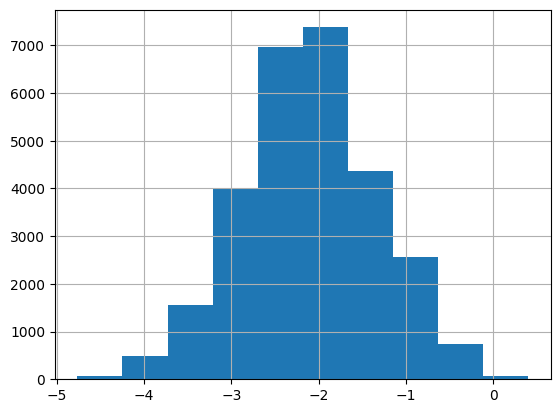

In [12]:
all_centrals_df['avg_SFR'].hist()

In [13]:
# this indicates that there are more instances of the delta rate on the left

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = all_centrals_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(all_centrals_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = all_centrals_df[all_centrals_df['subID'].isin(train_galaxies)]
    test_data = all_centrals_df[all_centrals_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    # XGBoost Regressor
    xgb_regressor = XGBRegressor(random_state=seed, n_jobs=-1)

    param_grid = {
    'n_estimators': [300],
    'max_depth': [2],
    'learning_rate': [0.01],
    'subsample': [0.6],
    'colsample_bytree': [1.0],
    'min_child_weight': [40,50],     
    'reg_alpha': [5],             
    'reg_lambda': [20]            
    }



    grid_search = GridSearchCV(
    estimator=xgb_regressor, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1, 
    verbose=2
    )

    grid_search.fit(X_train_scaled, y_train)

    best_xg_regressor = grid_search.best_estimator_

    best_xg_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_xg_regressor.predict(X_train_scaled)
    y_test_pred = best_xg_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_xg_regressor.feature_importances_)
#     print(random_search.best_params_)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 1: Train MSE = 0.2842, Test MSE = 0.2995
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 2: Train MSE = 0.2944, Test MSE = 0.2892
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 3: Train MSE = 0.2868, Test MSE = 0.2969
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 4: Train MSE = 0.2870, Test MSE = 0.2943
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 5: Train MSE = 0.2912, Test MSE = 0.2915
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 6: Train MSE = 0.2917, Test MSE = 0.2881
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 7: Train MSE = 0.2917, Test MSE = 0.2889
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 8: Train MSE = 0.2892, Test MSE = 0.2932
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Run 9: Train MSE = 0.2845, Test MSE = 0.2961
Fitting 5 folds for each of 2 candidates, totalling 10 


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.674292  0.021133
3      BHMass         0.129348  0.006602
0   bin_radii         0.117508  0.017563
2      s_mass         0.071794  0.011747
5    overdens         0.003905  0.006065
4       Mhalo         0.003153  0.005950


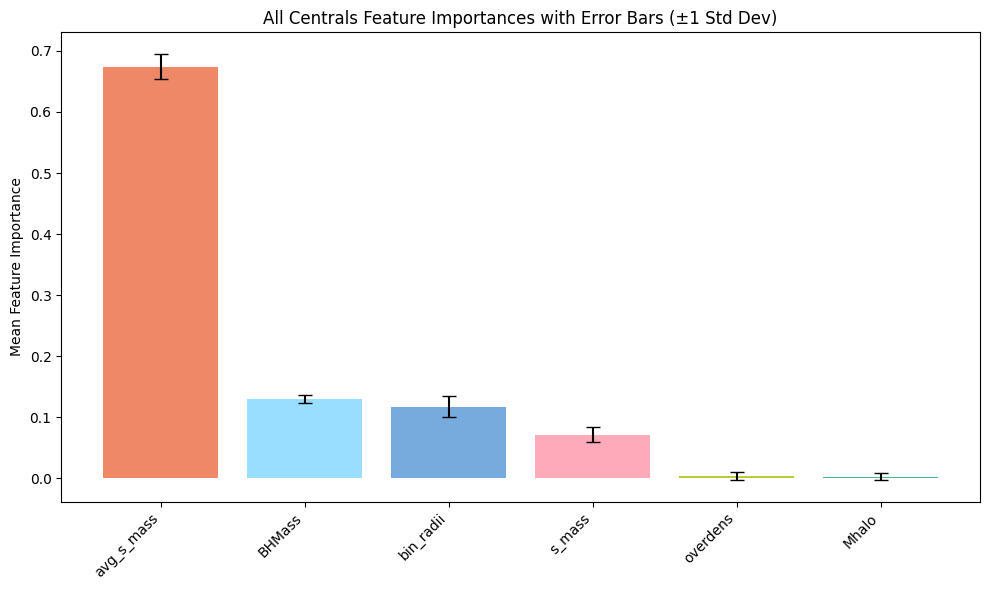

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("All Centrals Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [16]:
all_centrals_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens
subID,1.000000,-0.036832,-0.306676,-0.071245,-0.820910,-0.784682,-0.766101,-0.082170
bin_radii,-0.036832,1.000000,-0.768502,-0.513930,0.057778,0.039731,0.031903,0.004782
avg_s_mass,-0.306676,-0.768502,1.000000,0.646533,0.285263,0.295820,0.174055,0.013596
avg_SFR,-0.071245,-0.513930,0.646533,1.000000,-0.016633,-0.020691,-0.026555,-0.001129
s_mass,-0.820910,0.057778,0.285263,-0.016633,1.000000,0.915890,0.741029,0.109042
BHMass,-0.784682,0.039731,0.295820,-0.020691,0.915890,1.000000,0.771413,0.049938
Mhalo,-0.766101,0.031903,0.174055,-0.026555,0.741029,0.771413,1.000000,0.162239
overdens,-0.082170,0.004782,0.013596,-0.001129,0.109042,0.049938,0.162239,1.000000


In [17]:
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'all_centrals_xg_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_regression_outputs\all_centrals_xg_reg.csv


In [18]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'all_centrals_xg_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.29      0.29
DataFrame saved to xg_regression_outputs\all_centrals_xg_reg_mse.csv
